# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" 

import sys, tensorflow as tf
print("Python:", sys.executable)
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

2026-01-27 23:13:27.188939: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-27 23:13:27.197031: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-27 23:13:27.199989: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Python: /bin/python
TF: 2.17.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1769555609.474941   22136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769555609.581474   22136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769555609.581508   22136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [3]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

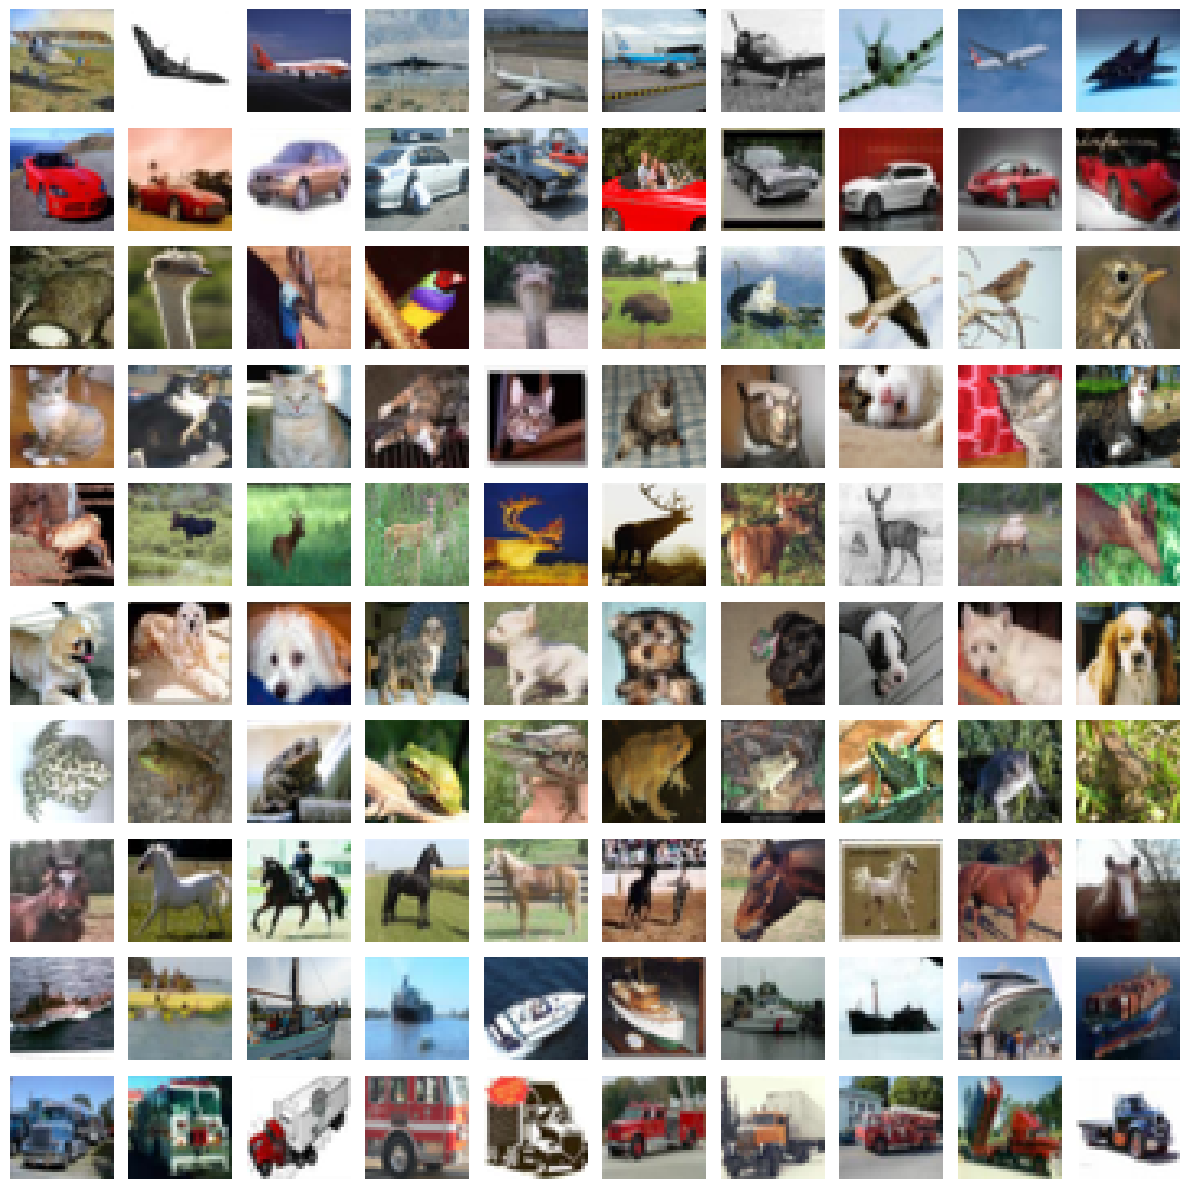

In [4]:
class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

plt.figure(figsize=(12, 12))
for class_id in range(10):
    class_indices = np.where(y_train.squeeze() == class_id)[0]
    chosen = np.random.choice(class_indices, 10, replace=False)
    for sample_pos, img_idx in enumerate(chosen):
        plt.subplot(10, 10, class_id*10 + sample_pos + 1)
        plt.imshow(x_train[img_idx])
        plt.axis("off")
        if sample_pos == 0:
            plt.ylabel(class_names[class_id], rotation=0, labelpad=40, va="center")
plt.tight_layout()
plt.show()


## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer. 

Use the input as (32,32,3). 

The filter maps can then be flattened to provide features to the classifier. 

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [5]:
from keras.backend import clear_session
clear_session()

In [6]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 7200)              0         
                                                                 
 dense (Dense)               (None, 100)               720100    
                                                                 
 dense_1 (Dense)             (None, 10)                1010      
                                                                 
Total params: 722006 (2.75 MB)
Trainable params: 722006 (2.75 MB)
Non-trainable params: 0 (0.00 Byte)
____________________

I0000 00:00:1769555664.346649   22136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769555664.346714   22136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769555664.346727   22136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769555664.471401   22136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769555664.471463   22136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [7]:
from tensorflow.keras.optimizers import SGD

model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/50


W0000 00:00:1769555681.169920   23672 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555681.194231   23672 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555681.217350   23672 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555681.217692   23672 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555681.218164   23672 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555681.218996   23672 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555681.243741   23672 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555681.245218   23672 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555681.247497   23672 gp

 3/98 [..............................] - ETA: 4s - loss: 2.3193 - accuracy: 0.0820  

W0000 00:00:1769555682.023840   23670 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555682.030340   23670 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1769555682.094790   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555682.095133   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555682.095368   23669 gpu_timer.cc:114] Skipping the delay kernel, measu

25/98 [======>.......................] - ETA: 1s - loss: 2.2414 - accuracy: 0.1720

...

98/98 [==============================] - 1s 5ms/step - loss: 1.0808 - accuracy: 0.6243 - val_loss: 1.1273 - val_accuracy: 0.6033
Epoch 12/50
26/98 [======>.......................] - ETA: 0s - loss: 1.0539 - accuracy: 0.6366

W0000 00:00:1769555688.037863   23668 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.038062   23668 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.038520   23668 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.038696   23668 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.038909   23668 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.039151   23668 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.039381   23668 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.039708   23668 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.039946   23668 gp

98/98 [==============================] - 0s 5ms/step - loss: 1.0504 - accuracy: 0.6358 - val_loss: 1.1164 - val_accuracy: 0.6112
Epoch 13/50
25/98 [======>.......................] - ETA: 0s - loss: 1.0098 - accuracy: 0.6518

W0000 00:00:1769555688.537035   23673 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.537236   23673 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.537385   23673 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.537566   23673 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.537775   23673 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.538017   23673 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.538242   23673 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.538568   23673 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769555688.538798   23673 gp

98/98 [==============================] - 0s 5ms/step - loss: 1.0187 - accuracy: 0.6469 - val_loss: 1.1345 - val_accuracy: 0.6025
Epoch 14/50
98/98 [==============================] - 0s 5ms/step - loss: 0.9806 - accuracy: 0.6614 - val_loss: 1.1042 - val_accuracy: 0.6037
Epoch 15/50
98/98 [==============================] - 0s 5ms/step - loss: 0.9634 - accuracy: 0.6667 - val_loss: 1.1046 - val_accuracy: 0.6171
Epoch 16/50
98/98 [==============================] - 0s 5ms/step - loss: 0.9239 - accuracy: 0.6823 - val_loss: 1.0505 - val_accuracy: 0.6352
Epoch 17/50
98/98 [==============================] - 0s 5ms/step - loss: 0.9028 - accuracy: 0.6874 - val_loss: 1.0442 - val_accuracy: 0.6364
Epoch 18/50
98/98 [==============================] - 1s 5ms/step - loss: 0.8739 - accuracy: 0.6984 - val_loss: 1.0420 - val_accuracy: 0.6353
Epoch 19/50
98/98 [==============================] - 0s 5ms/step - loss: 0.8491 - accuracy: 0.7079 - val_loss: 1.0263 - val_accuracy: 0.6422
Epoch 20/50
98/98 [======

*   Plot the cross entropy loss curve and the accuracy curve

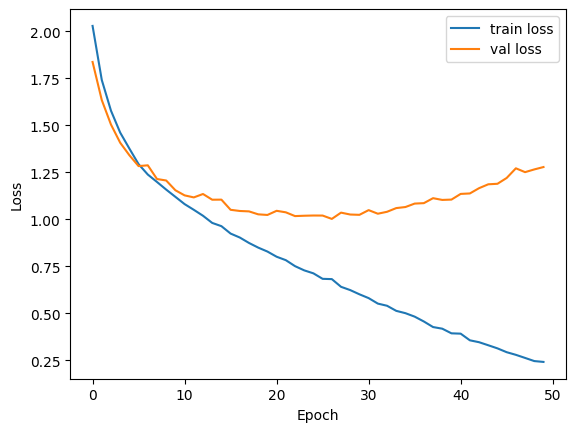

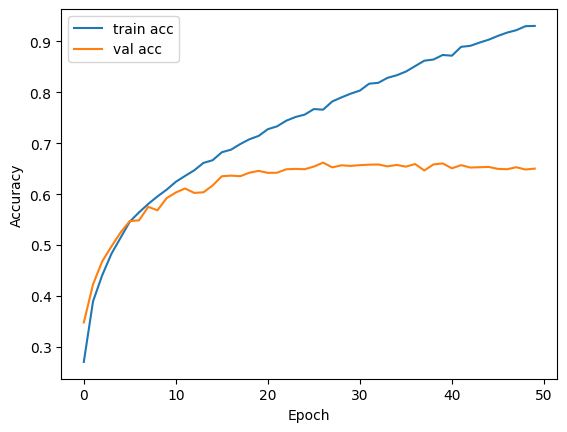

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3. 

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [9]:
from keras.backend import clear_session
clear_session()

In [15]:
import tensorflow as tf
vgg_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
])
vgg_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 conv2d_3 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 8192)              0         
                                                                 
 dense_2 (Dense)             (None, 100)               819300    
                                                                 
 dropout (Dropout)           (None, 100)               0         
                                                      

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [16]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
vgg_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    metrics=["accuracy"]
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
vgg_history = vgg_model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=512,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

15/98 [===>..........................] - ETA: 0s - loss: 2.2928 - accuracy: 0.1289

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

98/98 [==============================] - 2s 10ms/step - loss: 2.1039 - accuracy: 0.2300 - val_loss: 1.8559 - val_accuracy: 0.3605
Epoch 2/50
98/98 [==============================] - 1s 8ms/step - loss: 1.8562 - accuracy: 0.3410 - val_loss: 1.6696 - val_accuracy: 0.4144
Epoch 3/50
98/98 [==============================] - 1s 8ms/step - loss: 1.7054 - accuracy: 0.3963 - val_loss: 1.5421 - val_accuracy: 0.4638
Epoch 4/50
98/98 [==============================] - 1s 8ms/step - loss: 1.5996 - accuracy: 0.4320 - val_loss: 1.4550 - val_accuracy: 0.4825
Epoch 5/50
98/98 [==============================] - 1s 8ms/step - loss: 1.5231 - accuracy: 0.4542 - val_loss: 1.3866 - val_accuracy: 0.5156
Epoch 6/50
98/98 [==============================] - 1s 8ms/step - loss: 1.4540 - accuracy: 0.4780 - val_loss: 1.3423 - val_accuracy: 0.5260
Epoch 7/50
98/98 [==============================] - 1s 8ms/step - loss: 1.4090 - accuracy: 0.4966 - val_loss: 1.2830 - val_accuracy: 0.5444
Epoch 8/50
98/98 [============

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.
 

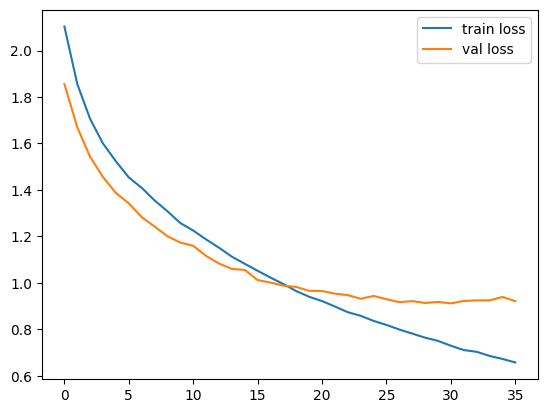

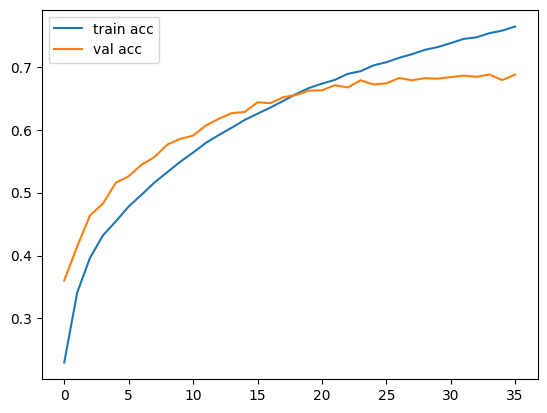

In [17]:
vgg_logs = vgg_history.history

plt.plot(vgg_logs["loss"], label="train loss")
plt.plot(vgg_logs["val_loss"], label="val loss")
plt.legend(); plt.show()

plt.plot(vgg_logs["accuracy"], label="train acc")
plt.plot(vgg_logs["val_accuracy"], label="val acc")
plt.legend(); plt.show()

**Comment on the observation**

*Most classes were able to be predicted correctly since the diagonal is strongest.*

...

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


W0000 00:00:1769557989.252587   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769557989.252908   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769557989.252993   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769557989.253846   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769557989.254598   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769557989.254989   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769557989.255172   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769557989.255316   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769557989.255555   23669 gp

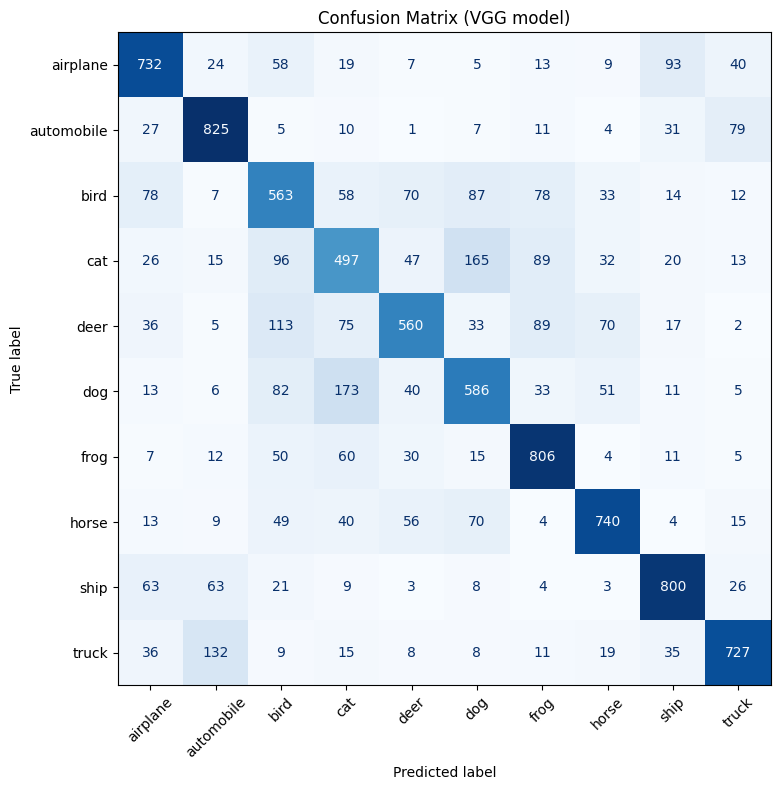

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

probabilities = vgg_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(probabilities, axis=1)
true_labels = y_test.squeeze()
cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
plt.title("Confusion Matrix (VGG model)")
plt.tight_layout()
plt.show()

**Comment here :**

*The biggest confusions happen between similar-looking classes (common in CIFAR-10), like cat vs dog, deer vs horse, automobile vs truck, and sometimes ship vs airplane depending on the images/background.*

...

*    Print the test accuracy for the trained model.

In [20]:
test_loss, test_acc = vgg_model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

base_loss, base_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Baseline test acc: {base_acc:.4f} | loss: {base_loss:.4f}")

Test accuracy: 0.6836 | Test loss: 0.9114


W0000 00:00:1769558531.225161   23671 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.225477   23671 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.225548   23671 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.225605   23671 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.225671   23671 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.225794   23671 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.225952   23671 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.226069   23671 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.226249   23671 gp

Baseline test acc: 0.6502 | loss: 1.2781


W0000 00:00:1769558531.951338   23666 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.951519   23666 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.951586   23666 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.951636   23666 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.951694   23666 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.951745   23666 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.951932   23666 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.952147   23666 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558531.952329   23666 gp

## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer. 

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling. 

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [21]:
from keras.backend import clear_session
clear_session()

In [22]:
import tensorflow as tf

complete_vgg_model = tf.keras.Sequential([
    # Resizing CIFAR-10
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Resizing(64, 64),
    # Block 1: MaxPool
    tf.keras.layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    tf.keras.layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    # Block 2: MaxPool
    tf.keras.layers.Conv2D(128, (3,3), padding="same", activation="relu"),
    tf.keras.layers.Conv2D(128, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    # Block 3: MaxPool
    tf.keras.layers.Conv2D(256, (3,3), padding="same", activation="relu"),
    tf.keras.layers.Conv2D(256, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    # Classifier head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])
complete_vgg_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing (Resizing)         (None, 64, 64, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 64)        1792      
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        36928     
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 64)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 32, 32, 128)       147584    
                                                        

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [24]:
from tensorflow.keras.optimizers import SGD

complete_vgg_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    metrics=["accuracy"]
)
complete_vgg_history = complete_vgg_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10


W0000 00:00:1769558750.676181   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558750.678116   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558750.680099   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558750.686138   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558750.692065   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558750.693655   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558750.702195   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558750.704297   23669 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558750.713093   23669 gp

 1/98 [..............................] - ETA: 4:44 - loss: 2.3016 - accuracy: 0.0957

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1769558753.227573   23668 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558753.230855   23668 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558753.235146   23668 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558753.246541   23668 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558753.250769   23668 gpu_timer.cc:114] Skipping the delay kernel, measu

 2/98 [..............................] - ETA: 2:14 - loss: 2.3022 - accuracy: 0.0947

...

98/98 [==============================] - 18s 159ms/step - loss: 2.2186 - accuracy: 0.1891 - val_loss: 2.1185 - val_accuracy: 0.2407
Epoch 2/10
 2/98 [..............................] - ETA: 7s - loss: 2.0873 - accuracy: 0.2539

W0000 00:00:1769558768.548389   23663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558768.553737   23663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558768.558198   23663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


98/98 [==============================] - ETA: 0s - loss: 1.9131 - accuracy: 0.3170

W0000 00:00:1769558776.793623   23663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558776.796540   23663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558776.799196   23663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558776.802025   23663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558776.804722   23663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558776.807134   23663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558776.809862   23663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558776.812695   23663 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1769558776.816335   23663 gp

98/98 [==============================] - 9s 92ms/step - loss: 1.9131 - accuracy: 0.3170 - val_loss: 1.7516 - val_accuracy: 0.3680
Epoch 3/10
98/98 [==============================] - 9s 91ms/step - loss: 1.6423 - accuracy: 0.4118 - val_loss: 1.5728 - val_accuracy: 0.4320
Epoch 4/10
98/98 [==============================] - 8s 84ms/step - loss: 1.4197 - accuracy: 0.4949 - val_loss: 1.3386 - val_accuracy: 0.5226
Epoch 5/10
98/98 [==============================] - 8s 83ms/step - loss: 1.2826 - accuracy: 0.5438 - val_loss: 1.2662 - val_accuracy: 0.5440
Epoch 6/10
98/98 [==============================] - 8s 82ms/step - loss: 1.1757 - accuracy: 0.5856 - val_loss: 1.1567 - val_accuracy: 0.5891
Epoch 7/10
98/98 [==============================] - 8s 83ms/step - loss: 1.0678 - accuracy: 0.6246 - val_loss: 1.1222 - val_accuracy: 0.6041
Epoch 8/10
98/98 [==============================] - 8s 84ms/step - loss: 0.9799 - accuracy: 0.6560 - val_loss: 1.0638 - val_accuracy: 0.6332
Epoch 9/10
98/98 [======

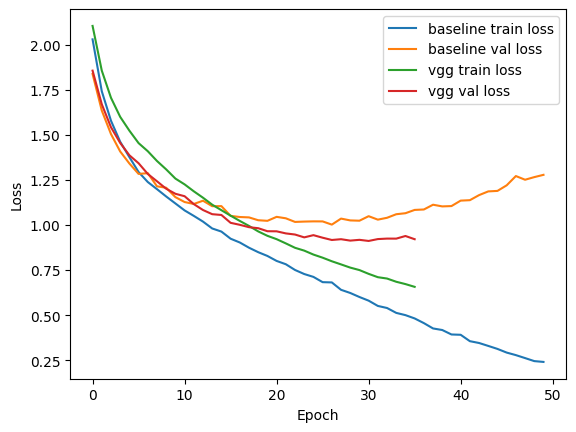

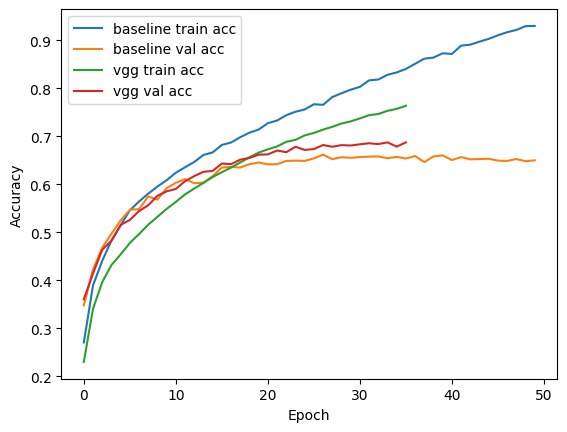

In [26]:
import matplotlib.pyplot as plt

base = history.history
vgg  = vgg_history.history
# Loss
plt.plot(base["loss"], label="baseline train loss")
plt.plot(base["val_loss"], label="baseline val loss")
plt.plot(vgg["loss"], label="vgg train loss")
plt.plot(vgg["val_loss"], label="vgg val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()
# Accuracy
plt.plot(base["accuracy"], label="baseline train acc")
plt.plot(base["val_accuracy"], label="baseline val acc")
plt.plot(vgg["accuracy"], label="vgg train acc")
plt.plot(vgg["val_accuracy"], label="vgg val acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()


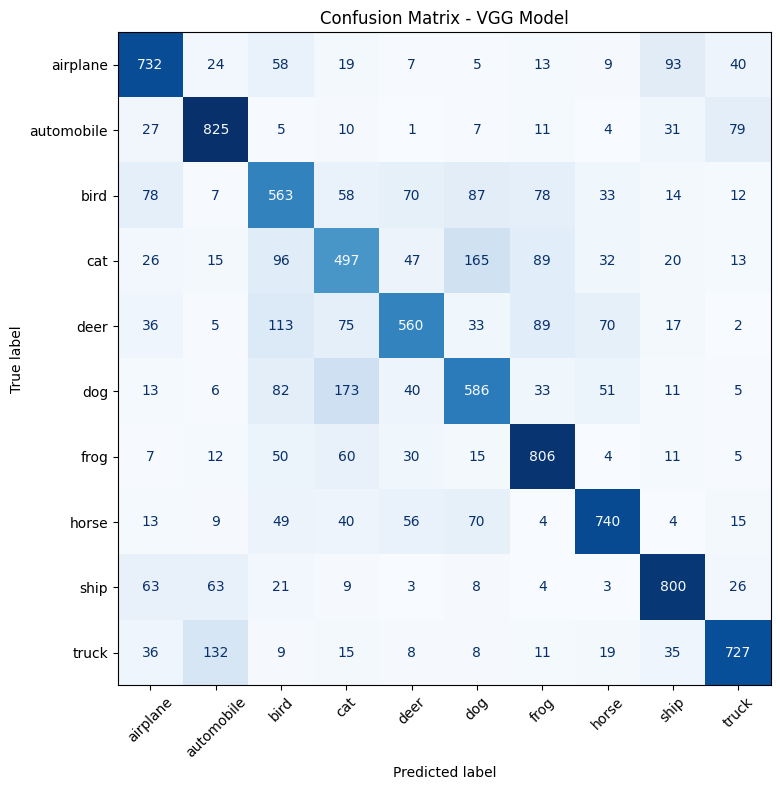

Top confusions:
dog → cat : 173
cat → dog : 165
truck → automobile : 132
deer → bird : 113
cat → bird : 96


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_probs = vgg_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.squeeze()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - VGG Model")
plt.tight_layout()
plt.show()

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
top = np.dstack(np.unravel_index(np.argsort(cm_no_diag.ravel())[::-1], cm_no_diag.shape))[0][:5]

print("Top confusions:")
for true_i, pred_i in top:
    print(f"{class_names[true_i]} → {class_names[pred_i]} : {cm[true_i, pred_i]}")

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions: 
- Activation functions add non-linearity to a neural network.
Without them, even with many layers, the whole network would behave like one big linear equation, so it couldn’t learn complex patterns. Helping how the model learns through backpropagation and control the flow of signals.


_

2 - Key Differences between sigmoid and softmax:  
Sigmoid:  
- Outputs a value between 0 and 1 for each neuron independently
- It is best for multi-label and binary classifications

Softmax:  
- Best for multi-class single-label classification
- Outputs probability distribution across classes. (adding up to 1)

_

3 - Key Differences between categorical crossentropy and binary crossentropy loss:
- Binary crossentropy is for yes/no problems (or multiple labels at once) and usually goes with sigmoid.
Categorical crossentropy is for choosing 1 class out of many (like CIFAR-10) and usually goes with softmax.
In Keras, sparse_categorical_crossentropy is the same idea as categorical crossentropy, but it lets you keep labels as integers (0–9) instead of one-hot.

_
